<center> 
<h1> Continuous time Mean-Variance Optimization </h1>
<p> Team members: <b>최승우, Nguyen Minh Duc, 문영진, 안영주</b> </p>
<p> IMEN786-01 - Advanced Investment Theory </p>
<p> Professor: <b>Jang Bong-Gyu</b> </p>
</center>

## Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from env import TradingEnv
from continuous_mvo import CapitalMarketLine, ContinuousMeanVarianceOptimization

Setting the visualization theme

In [3]:
sns.set_theme(style="whitegrid")

## Running the Continuous-time MVO formula by Zhou et al.

Create the trading environment with 10 stocks + 1 risky asset

The historical dates are for estimating the nominal annual interest and appriciation rate

The tradining dates are used for backtest the portfolio

In [16]:
BONDS_LIST = ['^TNX']
TICKER_LIST = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD']

In [4]:
env = TradingEnv(
    bonds_ticker=BONDS_LIST[0], # 10-Year Treasury Yield
    stocks_tickers=TICKER_LIST,
    # stocks_tickers=['NVDA'],
    historical_start_date='2018-01-01',
    historical_end_date='2023-01-01',
    start_trading_date='2023-01-01',
    end_trading_date='2024-01-01',
    use_sde=False,
)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

            Bonds Ticker: ^TNX
            Stocks Tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD']
            Historical Start Date: 2018-01-01
            Historical End Date: 2023-01-01
            Start Trading Date: 2023-01-01
            End Trading Date: 2024-01-01
            Use SDE: False
            Nominal Annual Appreciation: Ticker
AAPL     0.287461
MSFT     0.265836
GOOGL    0.148950
AMZN     0.133328
TSLA     0.565226
META     0.014218
NFLX     0.194735
NVDA     0.353042
INTC    -0.014489
AMD      0.516056
dtype: float64
            Nominal Annual Interest Rate: Ticker
^TNX    0.020638
dtype: float64
        


Initialize the Continuous-time MVO optimizer with an initial investment (`initial_funds`), and the desired rate of return (`target_return`)

In [5]:
optimizer = ContinuousMeanVarianceOptimization(env, initial_funds=1, target_return=0.20)

Using Equation (6.10), we can plot the capitial market line

In [6]:
print(f"Number of trading years: {optimizer.env.num_trading_years}")
print(f"Capital Market Line: {optimizer.capital_market_line}")

Number of trading years: 1.0
Capital Market Line: CapitalMarketLine(intercept=1.0208529129207315, slope=3.8355655577328105)


Required standard deviation for target return: 4.67%


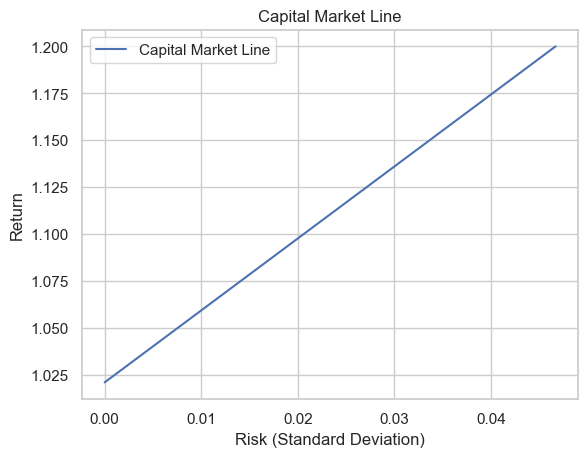

In [7]:
print(f"Required standard deviation for target return: {optimizer.sigma_T / optimizer.initial_funds * 100:.2f}%")
optimizer.capital_market_line.plot(optimizer.sigma_T)

Using Equation (5.12), we can obtain the optimal control for our portfolio

In [8]:
portfolio_weights, bonds_weight = optimizer.get_control(t=0.0, x=optimizer.initial_funds)
print(f"Optimal Portfolio Weights: {portfolio_weights}")
print(f"Bonds Weight: {bonds_weight}")

# Check if the weights sum to 1
print("Total Weights:", np.sum(portfolio_weights) + bonds_weight)

Optimal Portfolio Weights: [ 0.43888298  0.82482252 -0.17491051 -0.40766792  0.16349995 -0.33238732
  0.06432704  0.03798454 -0.61564279  0.25963529]
Bonds Weight: 0.7414562235267186
Total Weights: 1.0


Visualizing the portfolio performance in 2 settings: With rebalancing and without rebalancing

In this example, we assume that the time between rebalances are equal

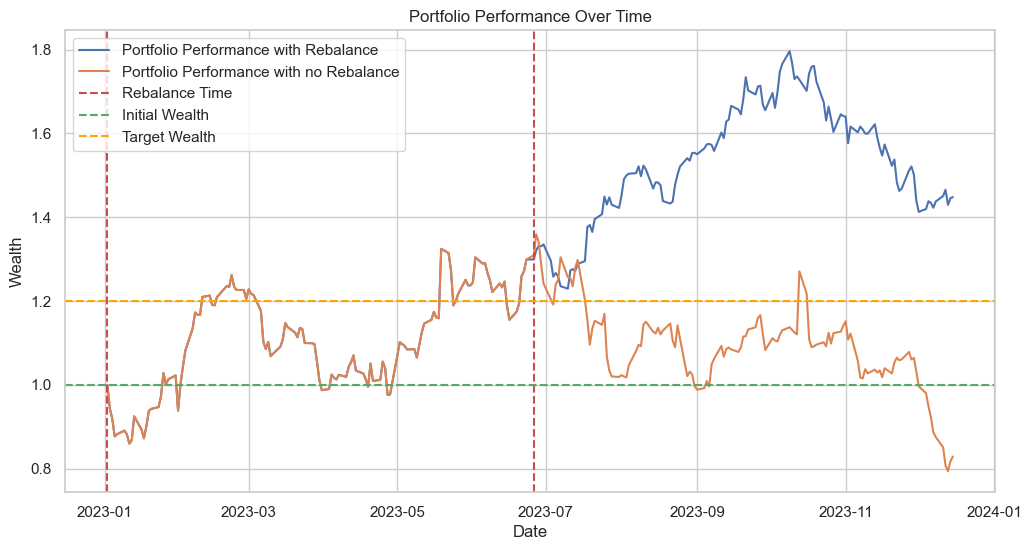

In [9]:
time_range = pd.date_range(start=env.start_trading_date, end=env.end_trading_date, freq='B')

# The number of rebalances
num_rebalances = 2
ts = np.linspace(0, env.num_trading_years, 1 + num_rebalances)

# The time between rebalances
dt = ts[1] - ts[0]
current_wealth = optimizer.initial_funds

# Plot the performance
plt.figure(figsize=(12, 6))

rebalanced_performances = []
rebalance_times = []
for t in ts[:-1]:
    portfolio_weights, bonds_weight = optimizer.get_control(t=t, x=current_wealth)
    combined_weights = np.concatenate([portfolio_weights, [bonds_weight]])
    performance = env.get_wealth_after_trading(combined_weights, t0=t, t1=t+dt) * current_wealth
    rebalanced_performances.extend(performance)
    current_wealth = performance[-1]
    rebalance_time = (t / ts[-1])
    rebalance_times.append(rebalance_time)

plt.plot(time_range[:len(rebalanced_performances)], rebalanced_performances, label='Portfolio Performance with Rebalance')

portfolio_weights, bonds_weight = optimizer.get_control(t=0.0, x=optimizer.initial_funds)
combined_weights = np.concatenate([portfolio_weights, [bonds_weight]])
no_rebalanced_performances = env.get_wealth_after_trading(combined_weights, t0=0.0, t1=env.num_trading_years) * optimizer.initial_funds
plt.plot(time_range[:len(no_rebalanced_performances)], no_rebalanced_performances, label='Portfolio Performance with no Rebalance')

for idx, rebalance_time in enumerate(rebalance_times):
    if idx == 0:
        plt.axvline(x=time_range[int(rebalance_time * len(rebalanced_performances))], color='r', linestyle='--', label='Rebalance Time')    
    else:
        plt.axvline(x=time_range[int(rebalance_time * len(rebalanced_performances))], color='r', linestyle='--')

plt.axhline(y=optimizer.initial_funds, color='g', linestyle='--', label='Initial Wealth')
plt.axhline(y=optimizer.target_wealth, color='orange', linestyle='--', label='Target Wealth')

plt.title('Portfolio Performance Over Time')
plt.xlabel('Date')
plt.ylabel('Wealth')
plt.legend()
plt.show()

## Computing the Sharpe Ratio on the performances of the 2 strategies

In [10]:
def calculate_sharpe_ratio(performance):
    returns = np.diff(performance) / performance[:-1]
    mean_return = np.mean(returns) * 252  # Annualize the mean return
    std_return = np.std(returns) * np.sqrt(252)  # Annualize the standard deviation
    sharpe_ratio = mean_return / std_return if std_return != 0 else 0
    return mean_return, std_return, sharpe_ratio

### Rebalancing strategy

In [11]:
rebalanced_mean, rebalanced_std, rebalanced_sharpe = calculate_sharpe_ratio(rebalanced_performances)
print(f"Rebalanced Portfolio Average Return: {rebalanced_mean * 100:.2f}%")
print(f"Rebalanced Portfolio Standard Deviation: {rebalanced_std * 100:.2f}%")
print(f"Rebalanced Portfolio Sharpe Ratio: {rebalanced_sharpe:.2f}")

Rebalanced Portfolio Average Return: 45.46%
Rebalanced Portfolio Standard Deviation: 40.14%
Rebalanced Portfolio Sharpe Ratio: 1.13


### No rebalancing strategy

In [12]:
no_rebalanced_mean, no_rebalanced_std, no_rebalanced_sharpe = calculate_sharpe_ratio(no_rebalanced_performances)
print(f"Rebalanced Portfolio Average Return: {no_rebalanced_mean * 100:.2f}%")
print(f"Rebalanced Portfolio Standard Deviation: {no_rebalanced_std * 100:.2f}%")
print(f"Rebalanced Portfolio Sharpe Ratio: {no_rebalanced_sharpe:.2f}")

Rebalanced Portfolio Average Return: -7.31%
Rebalanced Portfolio Standard Deviation: 48.44%
Rebalanced Portfolio Sharpe Ratio: -0.15


## Code to run multiple experiments

In [107]:
from pypfopt import EfficientFrontier, risk_models
def discrete_mvo(env: TradingEnv):
    prices = pd.concat([env.historical_stocks_data, env.historical_bonds_data], axis=1)
    S = risk_models.CovarianceShrinkage(prices).ledoit_wolf()
    # You don't have to provide expected returns in this case
    ef = EfficientFrontier(None, S, weight_bounds=(None, None))
    ef.min_volatility()
    weights = ef.clean_weights()
    return np.array(list(weights.values()))

def black_litterman(
    Sigma,          # N x N covariance matrix
    w_eq,           # N x 1 market cap weights
    delta,          # scalar risk aversion coefficient
    tau,            # scalar prior uncertainty parameter
    P,              # K x N view matrix
    Q,              # K x 1 view expected returns
    Omega           # K x K view covariance matrix
):
    # Step 1: Prior equilibrium returns
    Pi = delta * Sigma @ w_eq  # N x 1

    # Step 2: Compute posterior expected returns
    tau_sigma = tau * Sigma
    M_inverse = np.linalg.inv(np.linalg.inv(tau_sigma) + P.T @ np.linalg.inv(Omega) @ P)
    mu_bl = M_inverse @ (np.linalg.inv(tau_sigma) @ Pi + P.T @ np.linalg.inv(Omega) @ Q)

    # Step 3: Adjusted covariance matrix
    sigma_bl = Sigma + M_inverse 

    # Step 4: Final portfolio weights (unconstrained, mean-variance solution)
    w_star = (1 / delta) * np.linalg.inv(sigma_bl) @ mu_bl

    return mu_bl, w_star

def black_litterman_optimization(env: TradingEnv):
    mcaps = {}
    for ticker in env.stocks_tickers:
        mcap = yf.Ticker(ticker).info['marketCap']
        mcaps[ticker] = mcap
    mcaps[env.bonds_ticker] = 900_000_000_000
    market_weighted = np.array(list(mcaps.values()))
    w_eq = market_weighted / np.sum(market_weighted)
    delta = 2.5
    tau = 0.05
    prices = pd.concat([env.historical_stocks_data, env.historical_bonds_data], axis=1)
    S = risk_models.CovarianceShrinkage(prices).ledoit_wolf()

    P = np.array([
        # AAPL > MSFT + GOOGL by 5%
        [1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0],
        # GOOGL > 1/3 * AMZN + 2/3 * TSLA by 5%
        [0, 0, 1, -1/3, -2/3, 0, 0, 0, 0, 0, 0],
        # NVDA > INTC + AMD by 20%
        [0, 0, 0, 0, 0, 1, -1, -1, 0, 0, 0],
        # AAPL > 1/2 * META + 1/2 * NFLX by 5%
        [1, 0, 0, 0, 0, -1/2, -1/2, 0, 0, 0, 0],
    ])
    Q = np.array([
        0.05,
        0.05,
        0.20,
        0.05,
    ])
    omega = np.diag([0.01, 0.01, 0.01, 0.01])
    mu_bl, w_bl_star = black_litterman(S, w_eq, delta, tau, P, Q, omega)
    return w_bl_star

def compute_risk_parity_weights_newton(cov_matrix, tol=1e-8, max_iter=100):
    """
    Compute risk parity weights using Newton's method.

    Parameters:
    - cov_matrix: (n x n) numpy array, covariance matrix of asset returns
    - tol: float, convergence threshold for stopping iteration
    - max_iter: int, maximum number of iterations

    Returns:
    - weights: (n,) numpy array, portfolio weights satisfying risk parity condition
    """
    n = cov_matrix.shape[0]
    w = np.ones(n) / n  # inital value: same weights

    # toal portfolio variance function
    V = lambda w: np.sqrt(w @ cov_matrix @ w)

    for _ in range(max_iter):
        sigma_p = V(w)
        marginal_contrib = cov_matrix @ w            # ∂σ/∂w_i
        total_risk_contrib = w * marginal_contrib    # TRC_i = w_i * (Cw)_i

        # all asset's variance = TRC_i = σ^2 / n
        b = np.ones(n) / n
        f = total_risk_contrib - b * sigma_p**2

        if np.linalg.norm(f) < tol:
            break

        # calcuate Jacobian 
        J = np.diag(marginal_contrib) + np.outer(w, np.diag(cov_matrix)) - np.outer(marginal_contrib, w)
        try:
            delta = np.linalg.solve(J, f)
        except np.linalg.LinAlgError:
            raise ValueError("Jacobian is singular or ill-conditioned.")

        w = w - delta
        w = np.maximum(w, 0)      # ignore minus
        w = w / np.sum(w)         # normalize

    return w

def risk_parity_optimization(env: TradingEnv):
    prices = pd.concat([env.historical_stocks_data, env.historical_bonds_data], axis=1)
    S = risk_models.CovarianceShrinkage(prices).ledoit_wolf()
    weights = compute_risk_parity_weights_newton(S)
    return weights

def run_exp(
    bonds_ticker: str,
    stocks_tickers: list[str],
    historical_start_date: str,
    historical_end_date: str,
    start_trading_date: str,
    end_trading_date: str,
    initial_funds: float = 1_000_000,
    target_return: float = 0.10,
    num_rebalances: int = 2,
):
    """
    Run the experiment with the given parameters.
    """

    # Create the trading environment
    env = TradingEnv(
        bonds_ticker=bonds_ticker,
        stocks_tickers=stocks_tickers,
        historical_start_date=historical_start_date,
        historical_end_date=historical_end_date,
        start_trading_date=start_trading_date,
        end_trading_date=end_trading_date,
    )
    
    # Create the continuous-time mean-variance optimizer
    optimizer = ContinuousMeanVarianceOptimization(env, initial_funds=initial_funds, target_return=target_return)

    print(f"Number of trading years: {optimizer.env.num_trading_years}")
    print(f"Capital Market Line: {optimizer.capital_market_line}")    
    print(f"Required standard deviation for target return: {optimizer.sigma_T / optimizer.initial_funds * 100:.2f}%")
    optimizer.capital_market_line.plot(optimizer.sigma_T)

    time_range = pd.date_range(start=env.start_trading_date, end=env.end_trading_date, freq='B')

    # The number of rebalances
    ts = np.linspace(0, env.num_trading_years, 1 + num_rebalances)

    # The time between rebalances
    dt = ts[1] - ts[0]
    current_wealth = optimizer.initial_funds

    # Plot the performance
    plt.figure(figsize=(12, 6))

    rebalanced_performances = []
    rebalance_times = []
    for t in ts[:-1]:
        portfolio_weights, bonds_weight = optimizer.get_control(t=t, x=current_wealth)
        combined_weights = np.concatenate([portfolio_weights, [bonds_weight]])
        performance = env.get_wealth_after_trading(combined_weights, t0=t, t1=t+dt) * current_wealth
        rebalanced_performances.extend(performance)
        current_wealth = performance[-1]
        rebalance_time = (t / ts[-1])
        rebalance_times.append(rebalance_time)

    plt.plot(time_range[:len(rebalanced_performances)], rebalanced_performances, label='Portfolio Performance with Rebalance')

    portfolio_weights, bonds_weight = optimizer.get_control(t=0.0, x=optimizer.initial_funds)
    combined_weights = np.concatenate([portfolio_weights, [bonds_weight]])
    no_rebalanced_performances = env.get_wealth_after_trading(combined_weights, t0=0.0, t1=env.num_trading_years) * optimizer.initial_funds
    plt.plot(time_range[:len(no_rebalanced_performances)], no_rebalanced_performances, label='Portfolio Performance with no Rebalance')

    for idx, rebalance_time in enumerate(rebalance_times):
        if idx == 0:
            plt.axvline(x=time_range[int(rebalance_time * len(rebalanced_performances))], color='r', linestyle='--', label='Rebalance Time')    
        else:
            plt.axvline(x=time_range[int(rebalance_time * len(rebalanced_performances))], color='r', linestyle='--')

    # Discrete MVO
    discrete_weights = discrete_mvo(env)
    discrete_performances = env.get_wealth_after_trading(discrete_weights, t0=0.0, t1=env.num_trading_years) * optimizer.initial_funds
    plt.plot(time_range[:len(discrete_performances)], discrete_performances, label='Discrete MVO Performance')

    # Black-Litterman
    bl_weights = black_litterman_optimization(env)
    left_over = 1 - np.sum(bl_weights)
    bl_performances = env.get_wealth_after_trading(bl_weights, t0=0.0, t1=env.num_trading_years) * optimizer.initial_funds
    bl_performances += left_over * optimizer.initial_funds
    plt.plot(time_range[:len(bl_performances)], bl_performances, label='Black-Litterman Performance')

    # Risk Parity
    risk_parity_weights = risk_parity_optimization(env)
    risk_parity_performances = env.get_wealth_after_trading(risk_parity_weights, t0=0.0, t1=env.num_trading_years) * optimizer.initial_funds
    plt.plot(time_range[:len(risk_parity_performances)], risk_parity_performances, label='Risk Parity Performance')

    plt.axhline(y=optimizer.initial_funds, color='g', linestyle='--', label='Initial Wealth')
    plt.axhline(y=optimizer.target_wealth, color='orange', linestyle='--', label='Target Wealth')

    plt.title('Portfolio Performance Over Time')
    plt.xlabel('Date')
    plt.ylabel('Wealth')
    plt.legend()
    plt.show()

    # Calculate the Sharpe ratio
    rebalanced_mean, rebalanced_std, rebalanced_sharpe = calculate_sharpe_ratio(rebalanced_performances)
    print(f"Rebalanced Portfolio Average Return: {rebalanced_mean * 100:.2f}%")
    print(f"Rebalanced Portfolio Standard Deviation: {rebalanced_std * 100:.2f}%")
    print(f"Rebalanced Portfolio Sharpe Ratio: {rebalanced_sharpe:.2f}")
    print("=" * 50)
    no_rebalanced_mean, no_rebalanced_std, no_rebalanced_sharpe = calculate_sharpe_ratio(no_rebalanced_performances)
    print(f"No Rebalanced Portfolio Average Return: {no_rebalanced_mean * 100:.2f}%")
    print(f"No Rebalanced Portfolio Standard Deviation: {no_rebalanced_std * 100:.2f}%")
    print(f"No Rebalanced Portfolio Sharpe Ratio: {no_rebalanced_sharpe:.2f}")
    print("=" * 50)
    discrete_mean, discrete_std, discrete_sharpe = calculate_sharpe_ratio(discrete_performances)
    print(f"Discrete MVO Portfolio Average Return: {discrete_mean * 100:.2f}%")
    print(f"Discrete MVO Portfolio Standard Deviation: {discrete_std * 100:.2f}%")
    print(f"Discrete MVO Portfolio Sharpe Ratio: {discrete_sharpe:.2f}")
    print("=" * 50)
    bl_mean, bl_std, bl_sharpe = calculate_sharpe_ratio(bl_performances)
    print(f"Black-Litterman Portfolio Average Return: {bl_mean * 100:.2f}%")
    print(f"Black-Litterman Portfolio Standard Deviation: {bl_std * 100:.2f}%")
    print(f"Black-Litterman Portfolio Sharpe Ratio: {bl_sharpe:.2f}")
    print("=" * 50)
    risk_parity_mean, risk_parity_std, risk_parity_sharpe = calculate_sharpe_ratio(risk_parity_performances)
    print(f"Risk Parity Portfolio Average Return: {risk_parity_mean * 100:.2f}%")
    print(f"Risk Parity Portfolio Standard Deviation: {risk_parity_std * 100:.2f}%")
    print(f"Risk Parity Portfolio Sharpe Ratio: {risk_parity_sharpe:.2f}")

    """
    Create Latex table in the following format:
    \begin{table}[h]
    \centering
    \caption{Portfolio Performance Statistics (2022--2025)}
    \label{tab:portfolio-stats}
    \begin{tabular}{lccc}
    \toprule
    \textbf{Portfolio Strategy} & \textbf{Average Return} & \textbf{Standard Deviation} & \textbf{Sharpe Ratio}\\
    \midrule
    Rebalanced Portfolio & 45.46\% & 40.14\% & 1.13\\
    No Rebalanced Portfolio & -7.31\% & 48.44\% & -0.15\\
    \midrule
    other strategies... & ... & ... & ...\\
    \bottomrule
    \end{tabular}
    \end{table}
    """
    print(r"""Latex table:
\begin{{table}}[h]
\centering
\caption{{Portfolio Performance Statistics (2022--2025)}}
\label{{tab:portfolio-stats}}
\begin{{tabular}}{{lccc}}
\toprule
\textbf{{Portfolio Strategy}} & \textbf{{Average Return}} & \textbf{{Standard Deviation}} & \textbf{{Sharpe Ratio}}\\
\midrule
Continuous-MVO w/ Rebalanced & {:.2f}\% & {:.2f}\% & {:.2f}\\
Continuous-MVO wo/ Rebalanced & {:.2f}\% & {:.2f}\% & {:.2f}\\
\midrule
Discrete MVO & {:.2f}\% & {:.2f}\% & {:.2f}\\
Black-Litterman & {:.2f}\% & {:.2f}\% & {:.2f}\\
Risk Parity & {:.2f}\% & {:.2f}\% & {:.2f}\\
\bottomrule
\end{{tabular}}
\end{{table}}
    """.format(
        rebalanced_mean * 100, rebalanced_std * 100, rebalanced_sharpe,
        no_rebalanced_mean * 100, no_rebalanced_std * 100, no_rebalanced_sharpe,
        discrete_mean * 100, discrete_std * 100, discrete_sharpe,
        bl_mean * 100, bl_std * 100, bl_sharpe,
        risk_parity_mean * 100, risk_parity_std * 100, risk_parity_sharpe,
    ))

### 1-year investment period

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%*******

            Bonds Ticker: ^TNX
            Stocks Tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD']
            Historical Start Date: 2018-01-01
            Historical End Date: 2023-01-01
            Start Trading Date: 2023-01-01
            End Trading Date: 2024-01-01
            Use SDE: False
            Nominal Annual Appreciation: Ticker
AAPL     0.287461
MSFT     0.265836
GOOGL    0.148950
AMZN     0.133328
TSLA     0.565226
META     0.014218
NFLX     0.194735
NVDA     0.353042
INTC    -0.014489
AMD      0.516056
dtype: float64
            Nominal Annual Interest Rate: Ticker
^TNX    0.020638
dtype: float64
        
Number of trading years: 1.0
Capital Market Line: CapitalMarketLine(intercept=1020852.9129207316, slope=3.8355655577328105)
Required standard deviation for target return: 4.67%


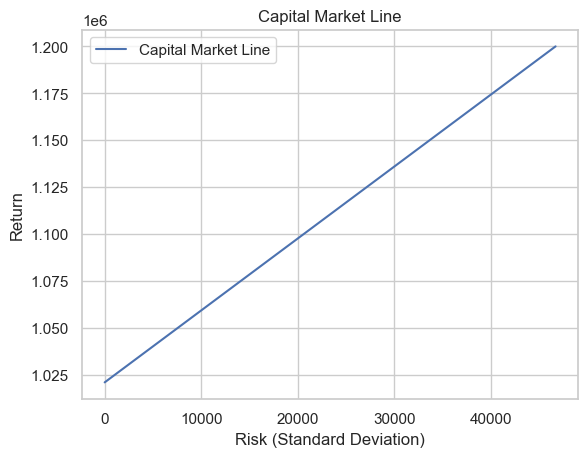

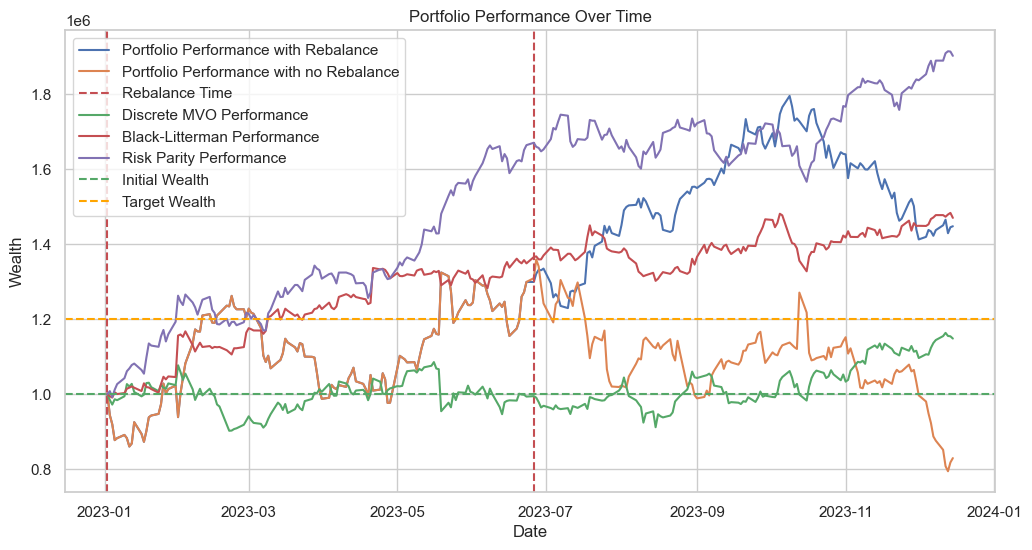

Rebalanced Portfolio Average Return: 45.46%
Rebalanced Portfolio Standard Deviation: 40.14%
Rebalanced Portfolio Sharpe Ratio: 1.13
No Rebalanced Portfolio Average Return: -7.31%
No Rebalanced Portfolio Standard Deviation: 48.44%
No Rebalanced Portfolio Sharpe Ratio: -0.15
Discrete MVO Portfolio Average Return: 17.88%
Discrete MVO Portfolio Standard Deviation: 27.75%
Discrete MVO Portfolio Sharpe Ratio: 0.64
Black-Litterman Portfolio Average Return: 41.30%
Black-Litterman Portfolio Standard Deviation: 21.43%
Black-Litterman Portfolio Sharpe Ratio: 1.93
Risk Parity Portfolio Average Return: 67.89%
Risk Parity Portfolio Standard Deviation: 23.26%
Risk Parity Portfolio Sharpe Ratio: 2.92
Latex table:
\begin{table}[h]
\centering
\caption{Portfolio Performance Statistics (2022--2025)}
\label{tab:portfolio-stats}
\begin{tabular}{lccc}
\toprule
\textbf{Portfolio Strategy} & \textbf{Average Return} & \textbf{Standard Deviation} & \textbf{Sharpe Ratio}\\
\midrule
Continuous-MVO w/ Rebalanced & 

In [108]:
run_exp(
    bonds_ticker='^TNX', # 10-Year Treasury Yield
    stocks_tickers=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD'],
    historical_start_date='2018-01-01',
    historical_end_date='2023-01-01',
    start_trading_date='2023-01-01',
    end_trading_date='2024-01-01',
    initial_funds=1_000_000,
    target_return=0.20, # 20% target return
    num_rebalances=2,
)

### 3-year investment period

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

            Bonds Ticker: ^TNX
            Stocks Tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD']
            Historical Start Date: 2017-01-01
            Historical End Date: 2022-01-01
            Start Trading Date: 2022-01-01
            End Trading Date: 2025-01-01
            Use SDE: False
            Nominal Annual Appreciation: Ticker
AAPL     0.421515
MSFT     0.389476
GOOGL    0.292530
AMZN     0.341209
TSLA     0.821496
META     0.267399
NFLX     0.383656
NVDA     0.604130
INTC     0.154596
AMD      0.665488
dtype: float64
            Nominal Annual Interest Rate: Ticker
^TNX    0.019384
dtype: float64
        
Number of trading years: 3.0027397260273974
Capital Market Line: CapitalMarketLine(intercept=1019572.9550722665, slope=5.664678230807522)
Required standard deviation for target return: 3.19%


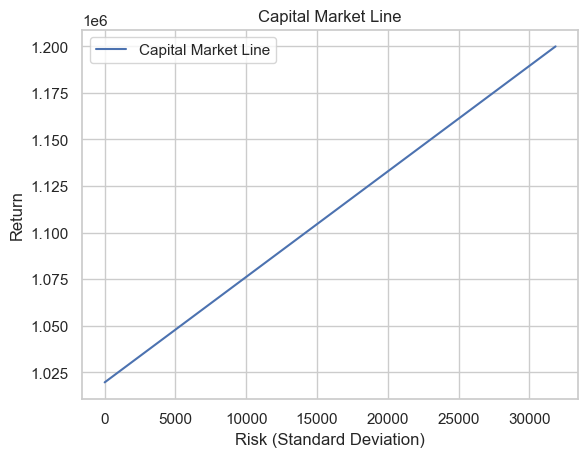

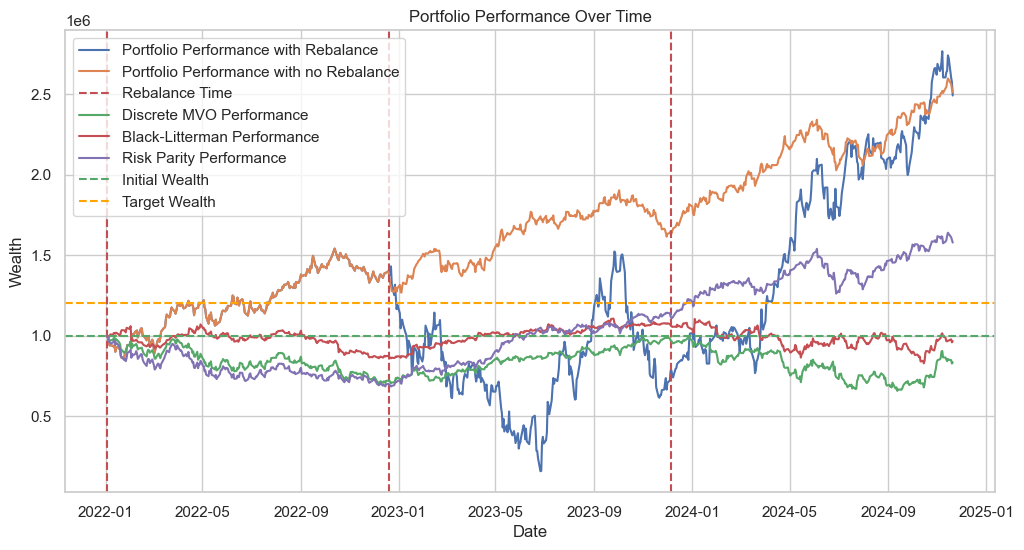

Rebalanced Portfolio Average Return: 87.81%
Rebalanced Portfolio Standard Deviation: 114.40%
Rebalanced Portfolio Sharpe Ratio: 0.77
No Rebalanced Portfolio Average Return: 34.03%
No Rebalanced Portfolio Standard Deviation: 25.02%
No Rebalanced Portfolio Sharpe Ratio: 1.36
Discrete MVO Portfolio Average Return: -2.16%
Discrete MVO Portfolio Standard Deviation: 28.08%
Discrete MVO Portfolio Sharpe Ratio: -0.08
Black-Litterman Portfolio Average Return: 0.92%
Black-Litterman Portfolio Standard Deviation: 20.50%
Black-Litterman Portfolio Sharpe Ratio: 0.04
Risk Parity Portfolio Average Return: 18.28%
Risk Parity Portfolio Standard Deviation: 24.43%
Risk Parity Portfolio Sharpe Ratio: 0.75
Latex table:
\begin{table}[h]
\centering
\caption{Portfolio Performance Statistics (2022--2025)}
\label{tab:portfolio-stats}
\begin{tabular}{lccc}
\toprule
\textbf{Portfolio Strategy} & \textbf{Average Return} & \textbf{Standard Deviation} & \textbf{Sharpe Ratio}\\
\midrule
Continuous-MVO w/ Rebalanced & 

In [109]:
run_exp(
    bonds_ticker='^TNX', # 10-Year Treasury Yield
    stocks_tickers=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD'],
    historical_start_date='2017-01-01',
    historical_end_date='2022-01-01',
    start_trading_date='2022-01-01',
    end_trading_date='2025-01-01',
    initial_funds=1_000_000,
    target_return=0.20, # 20% target return
    num_rebalances=3,
)

## Black-Litterman

In [68]:
def black_litterman(
    Sigma,          # N x N covariance matrix
    w_eq,           # N x 1 market cap weights
    delta,          # scalar risk aversion coefficient
    tau,            # scalar prior uncertainty parameter
    P,              # K x N view matrix
    Q,              # K x 1 view expected returns
    Omega           # K x K view covariance matrix
):
    # Step 1: Prior equilibrium returns
    Pi = delta * Sigma @ w_eq  # N x 1

    # Step 2: Compute posterior expected returns
    tau_sigma = tau * Sigma
    M_inverse = np.linalg.inv(np.linalg.inv(tau_sigma) + P.T @ np.linalg.inv(Omega) @ P)
    mu_bl = M_inverse @ (np.linalg.inv(tau_sigma) @ Pi + P.T @ np.linalg.inv(Omega) @ Q)

    # Step 3: Adjusted covariance matrix
    sigma_bl = Sigma + M_inverse 

    # Step 4: Final portfolio weights (unconstrained, mean-variance solution)
    w_star = (1 / delta) * np.linalg.inv(sigma_bl) @ mu_bl

    return mu_bl, w_star

In [69]:
def market_equilibrium(Sigma, w_eq, delta):

    Pi = delta * Sigma @ w_eq  # (N x 1)

    w_star = (1 / delta) * np.linalg.inv(Sigma) @ Pi

    return Pi, w_star

In [71]:
mcaps = {}
for t in TICKER_LIST:
    stock = yf.Ticker(t)
    mcaps[t] = stock.info["marketCap"]
mcaps

{'AAPL': 2965204369408,
 'MSFT': 3260878422016,
 'GOOGL': 1862480822272,
 'AMZN': 2049602093056,
 'TSLA': 960683573248,
 'META': 1489715462144,
 'NFLX': 485244567552,
 'NVDA': 2846259937280,
 'INTC': 93434036224,
 'AMD': 166744768512}

In [74]:
mcaps["^TNX"] = 900_000_000_000
mcaps

{'AAPL': 2965204369408,
 'MSFT': 3260878422016,
 'GOOGL': 1862480822272,
 'AMZN': 2049602093056,
 'TSLA': 960683573248,
 'META': 1489715462144,
 'NFLX': 485244567552,
 'NVDA': 2846259937280,
 'INTC': 93434036224,
 'AMD': 166744768512,
 '^TNX': 900000000000}

In [87]:
market_weighted = np.array(list(mcaps.values()))
market_weighted = market_weighted / np.sum(market_weighted)
market_weighted

array([0.17360429, 0.19091517, 0.10904296, 0.11999838, 0.05624529,
       0.08721861, 0.02840969, 0.16664043, 0.0054703 , 0.00976243,
       0.05269244])

In [88]:
print(TICKER_LIST + BONDS_LIST)

['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD', '^TNX']


In [89]:
delta = 2.5
tau = 0.05

# Covariance matrix
prices = pd.concat([env.historical_stocks_data, env.historical_bonds_data], axis=1)
S = risk_models.CovarianceShrinkage(prices).ledoit_wolf()

P = np.array([
    # AAPL > MSFT + GOOGL by 5%
    [1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0],
    # GOOGL > 1/3 * AMZN + 2/3 * TSLA by 5%
    [0, 0, 1, -1/3, -2/3, 0, 0, 0, 0, 0, 0],
    # NVDA > INTC + AMD by 20%
    [0, 0, 0, 0, 0, 1, -1, -1, 0, 0, 0],
    # AAPL > 1/2 * META + 1/2 * NFLX by 5%
    [1, 0, 0, 0, 0, -1/2, -1/2, 0, 0, 0, 0],
])
Q = np.array([
    0.05,
    0.05,
    0.20,
    0.05,
])
omega = np.diag([0.01, 0.01, 0.01, 0.01])


In [90]:
mu_bl, w_bl_star = black_litterman(S, market_weighted, delta, tau, P, Q, omega)

print("Posterior Expected Returns:", mu_bl)
print("Optimal Portfolio Weights:", w_bl_star)

Posterior Expected Returns: [0.12746371 0.0888961  0.09161832 0.08874889 0.0859257  0.16769605
 0.00974739 0.09736961 0.08191779 0.09811686 0.10023691]
Optimal Portfolio Weights: [ 0.38203176 -0.01087918 -0.00308063  0.08569348 -0.00361444  0.3387283
 -0.25259729 -0.10895337  0.00520981  0.00929755  0.05018328]


In [94]:
sum(w_bl_star)

np.float64(0.49201925134404684)

In [102]:
def compute_risk_parity_weights_newton(cov_matrix, tol=1e-8, max_iter=100):
    """
    Compute risk parity weights using Newton's method.

    Parameters:
    - cov_matrix: (n x n) numpy array, covariance matrix of asset returns
    - tol: float, convergence threshold for stopping iteration
    - max_iter: int, maximum number of iterations

    Returns:
    - weights: (n,) numpy array, portfolio weights satisfying risk parity condition
    """
    n = cov_matrix.shape[0]
    w = np.ones(n) / n  # inital value: same weights

    # toal portfolio variance function
    V = lambda w: np.sqrt(w @ cov_matrix @ w)

    for _ in range(max_iter):
        sigma_p = V(w)
        marginal_contrib = cov_matrix @ w            # ∂σ/∂w_i
        total_risk_contrib = w * marginal_contrib    # TRC_i = w_i * (Cw)_i

        # all asset's variance = TRC_i = σ^2 / n
        b = np.ones(n) / n
        f = total_risk_contrib - b * sigma_p**2

        if np.linalg.norm(f) < tol:
            break

        # calcuate Jacobian 
        J = np.diag(marginal_contrib) + np.outer(w, np.diag(cov_matrix)) - np.outer(marginal_contrib, w)
        try:
            delta = np.linalg.solve(J, f)
        except np.linalg.LinAlgError:
            raise ValueError("Jacobian is singular or ill-conditioned.")

        w = w - delta
        w = np.maximum(w, 0)      # ignore minus
        w = w / np.sum(w)         # normalize

    return w

In [104]:
S = risk_models.CovarianceShrinkage(prices).ledoit_wolf()
w_rp = compute_risk_parity_weights_newton(S)
print("Risk Parity Weights:", w_rp)
sum(w_rp)

Risk Parity Weights: [0.10081076 0.10366195 0.10631865 0.09843259 0.06904156 0.08778862
 0.08622248 0.06515865 0.10058113 0.06796211 0.11402148]


np.float64(0.9999999999999999)